In [1]:
rm(list =ls())

In [2]:
library(data.table)

In [3]:
TRYdata = fread("/workdir/sh2246/p_phyloGWAS/data/TRY_biomassAllometryTraits.txt")

Warning message in fread("/workdir/sh2246/p_phyloGWAS/data/TRY_biomassAllometryTraits.txt"):
“Found and resolved improper quoting out-of-sample. First healed line 338058: <<Kleyer	Michael	25	The LEDA Traitbase	Trifolium rubens	55001	Trifolium rubens	2386152	19650673			235	Comments, notes, methods	general comment	"spike", one or two flower head per single ramet											Kleyer, M., R. M. Bekker, I. C. Knevel, J. P. Bakker, K. Thompson, M. Sonnenschein, P. Poschlod, J. M. van Groenendael, L. Klimes, J. Klimesova, S. Klotz, G. M. Rusch, Hermy, M. , D. Adriaens, G. Boedeltje, B. Bossuyt, A. Dannemann, P. Endels, L. G<f6>tzenberger, J. G. Hodgson, A.-K. Jackel, I. K<fc>hn, D>>. If the fields are not quoted (e.g. field separator does not appear within any field), try quote="" to avoid this warning.”


In [6]:
dim(TRYdata)

[1] 2339823      29

In [8]:
length(unique(TRYdata$AccSpeciesName))
length(unique(TRYdata$TraitID))

[1] 5538

[1] 166

In [32]:
head(TRYdata)

LastName,FirstName,DatasetID,Dataset,SpeciesName,AccSpeciesID,AccSpeciesName,ObservationID,ObsDataID,TraitID,⋯,Replicates,StdValue,UnitName,RelUncertaintyPercent,OrigObsDataID,ErrorRisk,Reference,Comment,StdValueStr,V29
<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,⋯,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Shipley,Bill,50,Leaf and Whole Plant Traits Database,Achillea millefolium,909,Achillea millefolium,93134,1005906,117,⋯,,NA,,NA,NA,NA,"Shipley, B. and T. T. Vu. 2002. Dry matter content as a measure of dry matter concentration in plants and their parts. New Phytologist 153:359-364.",DMConc (g/cm3): dry matter concentration,,NA
Shipley,Bill,50,Leaf and Whole Plant Traits Database,Achillea millefolium,909,Achillea millefolium,93134,1005910,119,⋯,,NA,,NA,NA,NA,"Shipley, B. and T. T. Vu. 2002. Dry matter content as a measure of dry matter concentration in plants and their parts. New Phytologist 153:359-364.",DMCont (g/g): dry matter content,,NA
Shipley,Bill,50,Leaf and Whole Plant Traits Database,Achillea millefolium,909,Achillea millefolium,93134,1005912,NA,⋯,,NA,,NA,NA,NA,"Shipley, B. and T. T. Vu. 2002. Dry matter content as a measure of dry matter concentration in plants and their parts. New Phytologist 153:359-364.",Exposition,Growth chamber,NA
Shipley,Bill,50,Leaf and Whole Plant Traits Database,Achillea millefolium,909,Achillea millefolium,93134,1005913,NA,⋯,,NA,,NA,NA,NA,"Shipley, B. and T. T. Vu. 2002. Dry matter content as a measure of dry matter concentration in plants and their parts. New Phytologist 153:359-364.",Nsupply,,NA
Shipley,Bill,50,Leaf and Whole Plant Traits Database,Achillea millefolium,909,Achillea millefolium,93134,1005914,NA,⋯,,NA,,NA,NA,NA,"Shipley, B. and T. T. Vu. 2002. Dry matter content as a measure of dry matter concentration in plants and their parts. New Phytologist 153:359-364.",Tday,,NA
Shipley,Bill,50,Leaf and Whole Plant Traits Database,Achillea millefolium,909,Achillea millefolium,93134,1005915,NA,⋯,,NA,,NA,NA,NA,"Shipley, B. and T. T. Vu. 2002. Dry matter content as a measure of dry matter concentration in plants and their parts. New Phytologist 153:359-364.",Tnight,,NA


In [13]:
envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_759Poaceae_20240821.txt")

In [14]:
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"

In [16]:
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_2024.08.21.csv",header = T)

In [20]:
spNameMetadata = read.delim("/workdir/sh2246/p_phyloGWAS/data/spNameMetadata_20240819.txt")

In [22]:
dim(spNameMetadata)

[1] 671   2

In [80]:
commonSp = unique(TRYdata$AccSpeciesName)[unique(TRYdata$AccSpeciesName)%in%c(spNameMetadata$names,metadata$correctSpecies)]

In [84]:
TRYdata_subset = subset(TRYdata, AccSpeciesName %in%commonSp)

In [85]:
TRYdata_subset = TRYdata_subset[!is.na(TRYdata_subset$TraitID),]

In [86]:
dim(TRYdata_subset)

[1] 20625    29

In [87]:
goodTrait = names(which(apply(table(TRYdata_subset$TraitID,TRYdata_subset$AccSpeciesID),1,function(x) sum(x!=0))>=48))

In [88]:
TRYdata_subset = subset(TRYdata_subset,TraitID %in% goodTrait)

In [89]:
dim(TRYdata_subset)

[1] 8460   29

In [90]:
unique(TRYdata_subset$TraitName)

[1] "Plant biomass and allometry: Leaf dry mass per plant dry mass (leaf weight ratio, LWR)"              
[2] "Plant biomass and allometry: Stem dry mass per plant"                                                
[3] "Plant biomass and allometry: Leaf dry mass per plant"                                                
[4] "Plant biomass and allometry: Root dry mass per plant"                                                
[5] "Plant biomass and allometry: Plant dry mass"                                                         
[6] "Plant biomass and allometry: Root mass fraction (fraction of root dry mass per whole plant dry mass)"
[7] "Plant biomass and allometry: Stem dry mass per plant dry mass"

In [102]:
dim(table(TRYdata_subset$AccSpeciesID,TRYdata_subset$TraitID))

[1] 67  7

In [104]:
length(unique(TRYdata_subset$AccSpeciesID))

[1] 67

In [243]:
TRYdata_subset$TraitVal = as.numeric(TRYdata_subset$OrigValueStr)

In [245]:
TRYdata_subset$TraitVal[TRYdata_subset$OrigUnitStr == 'mg'] = TRYdata_subset$TraitVal[TRYdata_subset$OrigUnitStr == 'mg']/1000

In [289]:
unique(TRYdata_subset$Reference[TRYdata_subset$AccSpeciesName=="Zea mays"])

[1] "Shipley B., 2002. Trade-offs between net assimilation rate and specific leaf area in determining relative growth rate: relationship with daily irradiance, Functional Ecology(16) 682-689"                                                                                                                                                                                                      
[2] "MENCUCCINI M., 2003. The ecological significance of long distance water transport: short-term regulation and long-term acclimation across plant growth forms. Plant, Cell and Environment, 26:163-182."                                                                                                                                                                                         
[3] "Poorter , Andrzej M. Jagodzinski2,3, Ricardo Ruiz-Peinado4,5, Shem Kuyah6, Yunjian Luo7,8, Jacek Oleksyn2,9, Vladimir A. Usoltsev10,11, Thomas N. Buckley12, Peter B. Reich9,13 and Lawren Sac; How does biomass distribution change with size and differ among species? An analysis for 1200 plant species from five continents; New Phytologist (2015) 208: 736\x96749 doi: 10.1111/nph.13571"
[4] "Reichenau, T. G., Korres, W., Schmidt, M., Graf, A., Welp, G.,  Meyer, N., Stadler, A., Brogi, C., Schneider, K. (2020) A comprehensive dataset of vegetation states, fluxes of matter and energy, weather, agricultural management, and soil properties from intensively monitored crop sites in western Germany. Earth System Sciences Data, 12, doi:10.5194/essd-12-2333-2020"

In [246]:
library(reshape2)

# Use dcast to transform the data frame
outTab <- dcast(TRYdata_subset, AccSpeciesName~TraitName , mean, value.var = "TraitVal")


In [247]:
rownames(outTab) = outTab[,1]

In [248]:
colnames(outTab)[1] = "names"

In [249]:
outTab = merge(outTab,spNameMetadata,by = "names",all.x = T)

In [250]:
outTab = merge(outTab,metadata[,c(3,8)],by.x = "latest_name",by.y= "correctSpecies")

In [251]:
outTab = outTab[!duplicated(outTab$latest_name),]

In [252]:
outTab[outTab[,10]=="annual or perennial",]

,latest_name,names,Plant biomass and allometry: Leaf dry mass per plant,"Plant biomass and allometry: Leaf dry mass per plant dry mass (leaf weight ratio, LWR)",Plant biomass and allometry: Plant dry mass,Plant biomass and allometry: Root dry mass per plant,Plant biomass and allometry: Root mass fraction (fraction of root dry mass per whole plant dry mass),Plant biomass and allometry: Stem dry mass per plant,Plant biomass and allometry: Stem dry mass per plant dry mass,lifeHistory
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
102,Sorghum arundinaceum,Sorghum arundinaceum,0.9689867,0.1473333,6.687367,4.792477,0.713,0.9259033,0.1396667,annual or perennial


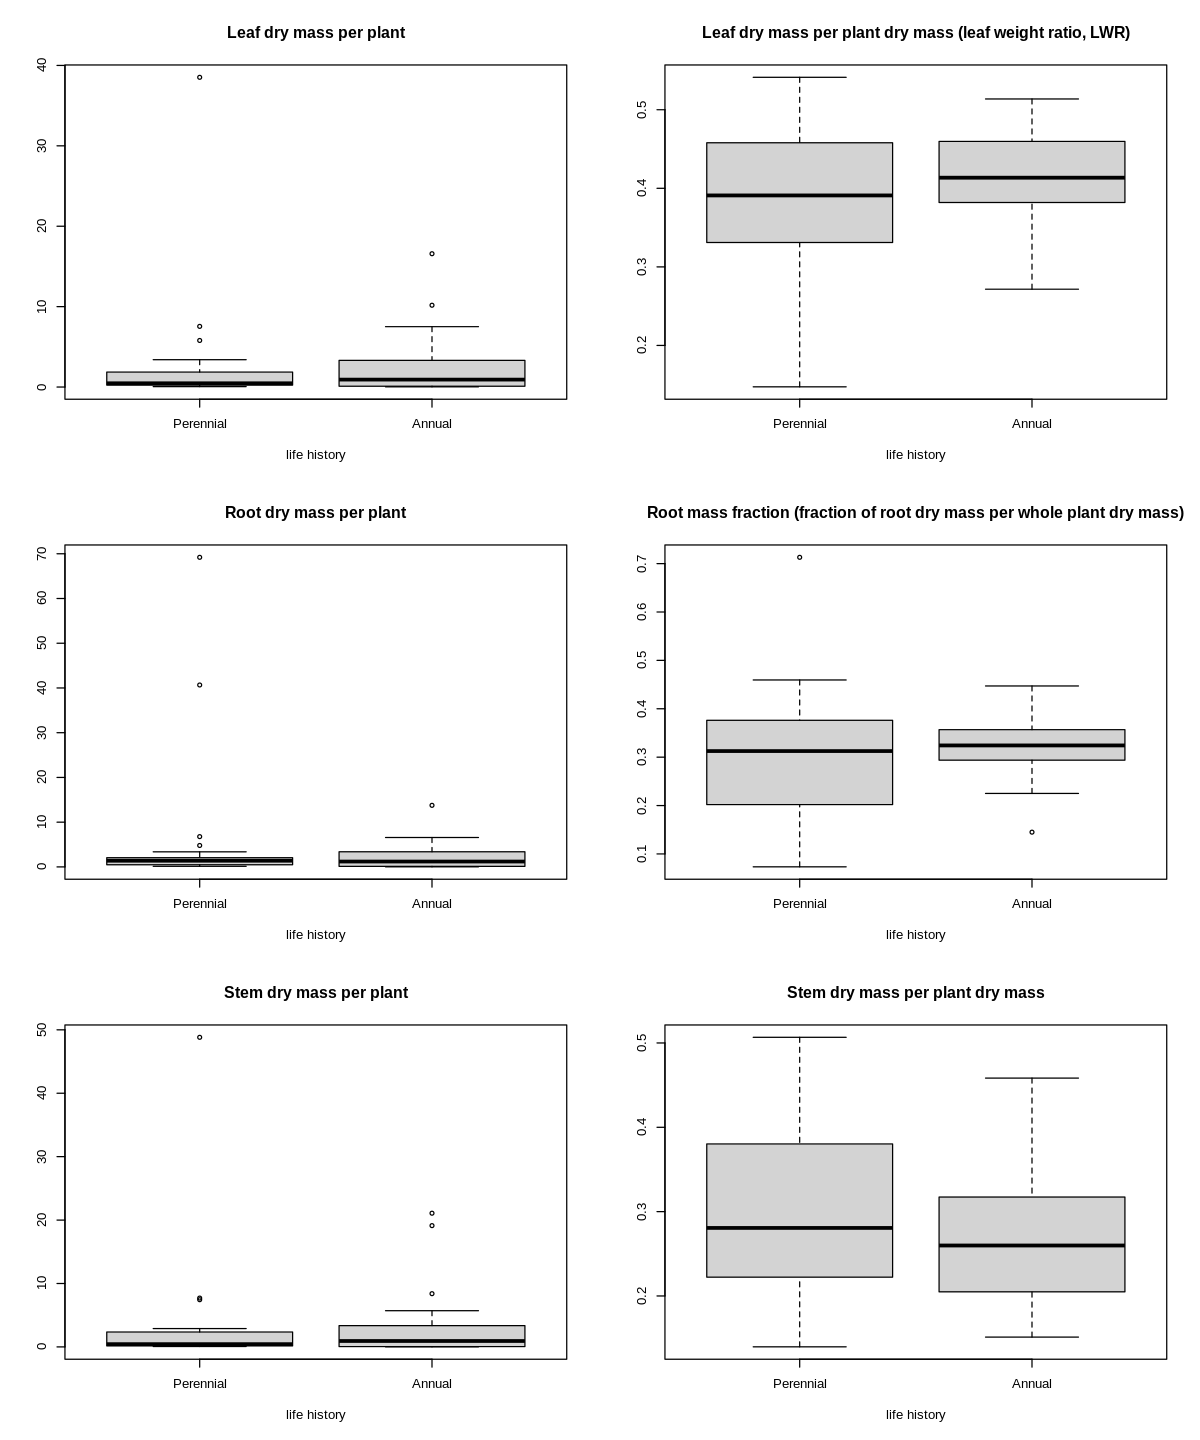

In [253]:
options(repr.plot.width=10, repr.plot.height=12)

par(mfrow=c(3,2))
for(i in c(1,2,4,5,6,7)){
    boxplot(outTab[,i+2]~outTab[,10]=="annual",main = limma::strsplit2(colnames(outTab)[i+2],": ")[,2],
           xlab = "life history",ylab = "",names = c("Perennial","Annual"))
}


In [270]:
for(i in c(1,2,4,5,6,7)){
    print(t.test(outTab[outTab$lifeHistory=="annual",2+i],outTab[outTab$lifeHistory!="annual",2+i],alternative = "less")$'p.value')
}

[1] 0.3437205
[1] 0.8374445
[1] 0.1200068
[1] 0.6235429
[1] 0.3513184
[1] 0.09766245


In [268]:
tmp = t.test(outTab[outTab$lifeHistory=="annual",2+i],outTab[outTab$lifeHistory!="annual",2+i],alternative = "less")
tmp$


	Welch Two Sample t-test

data:  outTab[outTab$lifeHistory == "annual", 2 + i] and outTab[outTab$lifeHistory != "annual", 2 + i]
t = -1.3358, df = 21.933, p-value = 0.09766
alternative hypothesis: true difference in means is less than 0
95 percent confidence interval:
       -Inf 0.01196389
sample estimates:
mean of x mean of y 
0.2699478 0.3118244 


In [255]:
cor(outTab[,-c(1:2,10)],use = "complete")

,Plant biomass and allometry: Leaf dry mass per plant,"Plant biomass and allometry: Leaf dry mass per plant dry mass (leaf weight ratio, LWR)",Plant biomass and allometry: Plant dry mass,Plant biomass and allometry: Root dry mass per plant,Plant biomass and allometry: Root mass fraction (fraction of root dry mass per whole plant dry mass),Plant biomass and allometry: Stem dry mass per plant,Plant biomass and allometry: Stem dry mass per plant dry mass
Plant biomass and allometry: Leaf dry mass per plant,1.0000000,-0.3034369,0.98571857,0.91855288,-0.14515135,0.9828881,0.3832967
"Plant biomass and allometry: Leaf dry mass per plant dry mass (leaf weight ratio, LWR)",-0.3034369,1.0000000,-0.30653369,-0.33898948,-0.42446374,-0.2875388,-0.3031835
Plant biomass and allometry: Plant dry mass,0.9857186,-0.3065337,1.00000000,0.96524077,-0.07983862,0.9629137,0.3271790
Plant biomass and allometry: Root dry mass per plant,0.9185529,-0.3389895,0.96524077,1.00000000,0.08263065,0.8902607,0.1922328
Plant biomass and allometry: Root mass fraction (fraction of root dry mass per whole plant dry mass),-0.1451514,-0.4244637,-0.07983862,0.08263065,1.00000000,-0.1570758,-0.7142962
Plant biomass and allometry: Stem dry mass per plant,0.9828881,-0.2875388,0.96291367,0.89026073,-0.15707580,1.0000000,0.3847388
Plant biomass and allometry: Stem dry mass per plant dry mass,0.3832967,-0.3031835,0.32717898,0.19223275,-0.71429620,0.3847388,1.0000000


In [256]:
rownames(outTab) = outTab[,1]

In [257]:
bioMassData = na.omit(outTab[,c(3,6,8)])
bioMassData

DWFrac = na.omit(outTab[,c(4,7,9)])
DWFrac

,Plant biomass and allometry: Leaf dry mass per plant,Plant biomass and allometry: Root dry mass per plant,Plant biomass and allometry: Stem dry mass per plant
,<dbl>,<dbl>,<dbl>
Aegilops cylindrica,0.05644333,0.02604333,0.03561333
Aegilops geniculata,0.10031500,0.06668250,0.04986250
Aegilops longissima,0.06350667,0.02617333,0.02437333
Aegilops searsii,0.04397667,0.02359667,0.02084000
Aegilops speltoides,0.64310333,0.77973333,0.41978500
Aegilops tauschii,1.89128222,1.85275000,1.77341667
Aegilops triuncialis,2.40860429,1.26503286,2.89358000
Aegilops umbellulata,0.05839333,0.04204333,0.03074667
Aegilops ventricosa,0.09001333,0.04220667,0.04520000


,"Plant biomass and allometry: Leaf dry mass per plant dry mass (leaf weight ratio, LWR)",Plant biomass and allometry: Root mass fraction (fraction of root dry mass per whole plant dry mass),Plant biomass and allometry: Stem dry mass per plant dry mass
,<dbl>,<dbl>,<dbl>
Aegilops cylindrica,0.4777143,0.30366667,0.2453333
Aegilops geniculata,0.4558889,0.35525000,0.2067500
Aegilops longissima,0.5043714,0.31170000,0.1914333
Aegilops searsii,0.4741333,0.32686667,0.2015333
Aegilops speltoides,0.4597000,0.35600000,0.2128333
Aegilops tauschii,0.4167692,0.32566667,0.2823333
Aegilops triuncialis,0.4519917,0.29254286,0.2853286
Aegilops umbellulata,0.4597143,0.35766667,0.2030000
Aegilops ventricosa,0.4911429,0.31533333,0.2116667


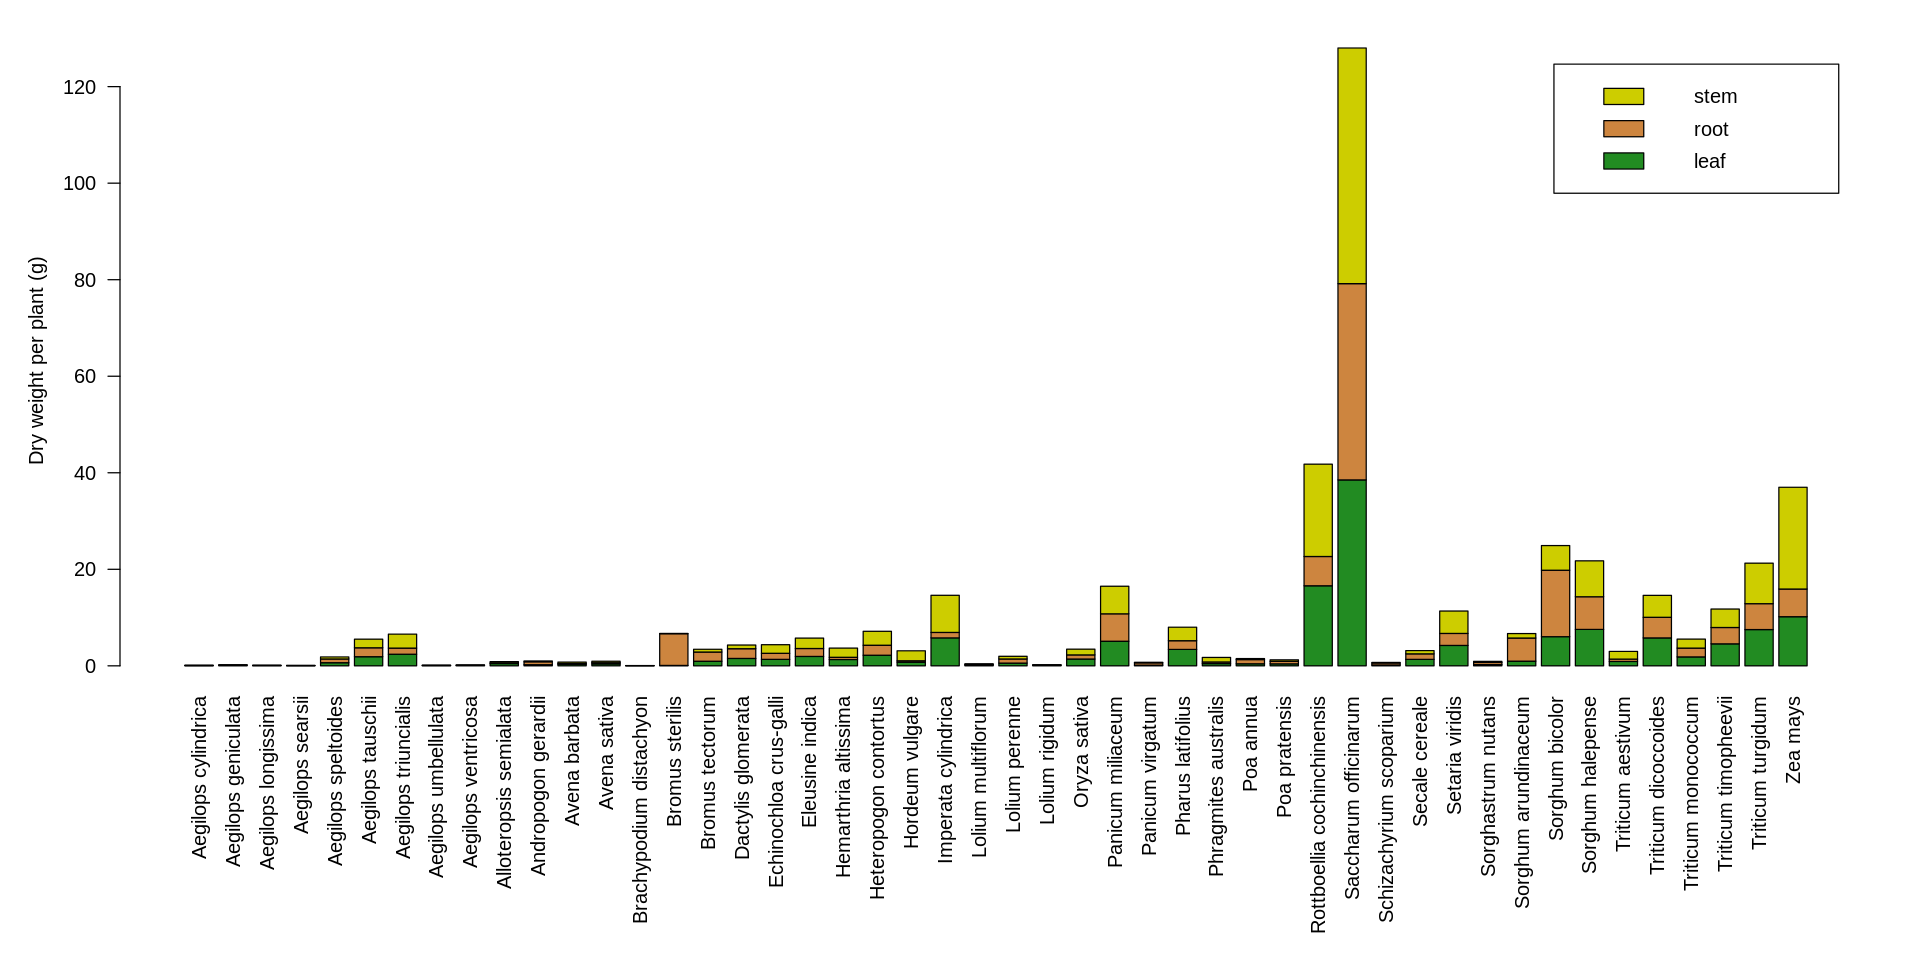

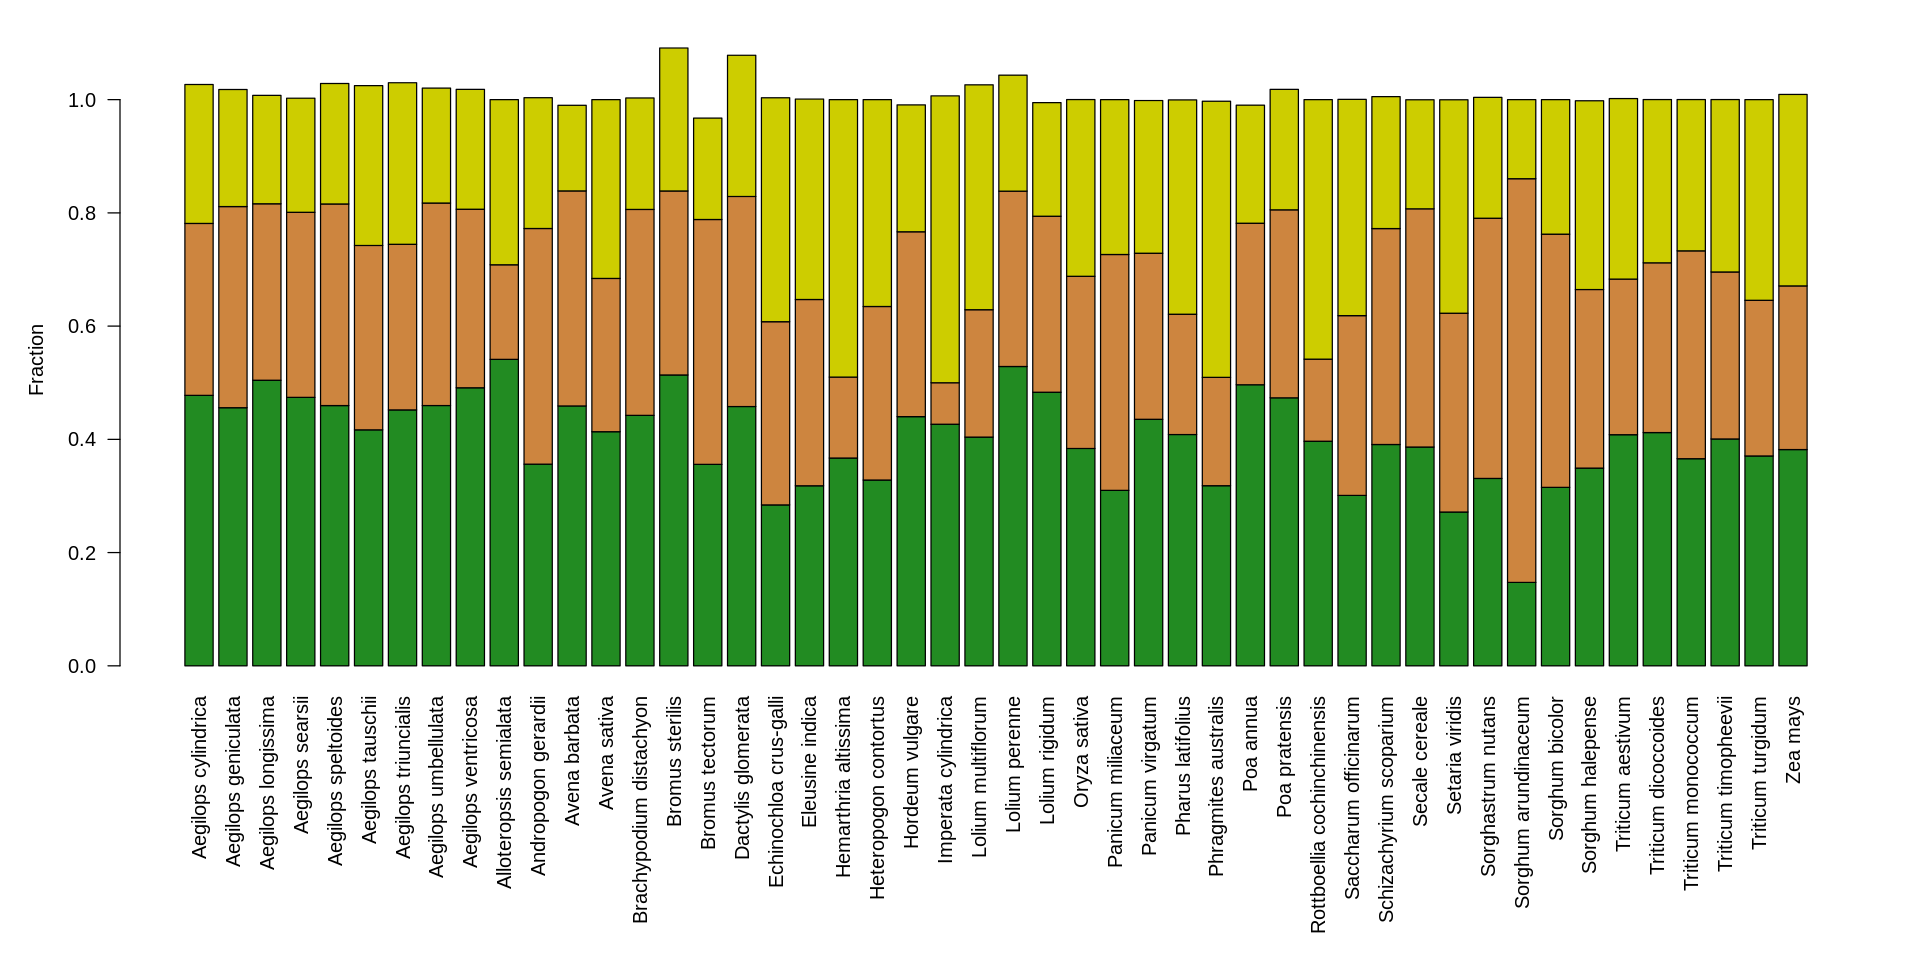

In [278]:
options(repr.plot.width=16, repr.plot.height=8)
par(mar = c(12,5,2,2))
barplot(t(bioMassData),las = 2,legend.text = c("leaf","root","stem"),ylab = "Dry weight per plant (g)",
        col = c("forestgreen","peru","yellow3"))
par(mar = c(12,5,2,2))
barplot(t(DWFrac),las = 2,ylab = "Fraction",col = c("forestgreen","peru","yellow3"))

In [282]:
DWFrac["Zea mays",]

,"Plant biomass and allometry: Leaf dry mass per plant dry mass (leaf weight ratio, LWR)",Plant biomass and allometry: Root mass fraction (fraction of root dry mass per whole plant dry mass),Plant biomass and allometry: Stem dry mass per plant dry mass
,<dbl>,<dbl>,<dbl>
Zea mays,0.3819459,0.2890556,0.3381944


In [284]:
0.71/0.29
0.29/0.71

[1] 2.448276

[1] 0.4084507